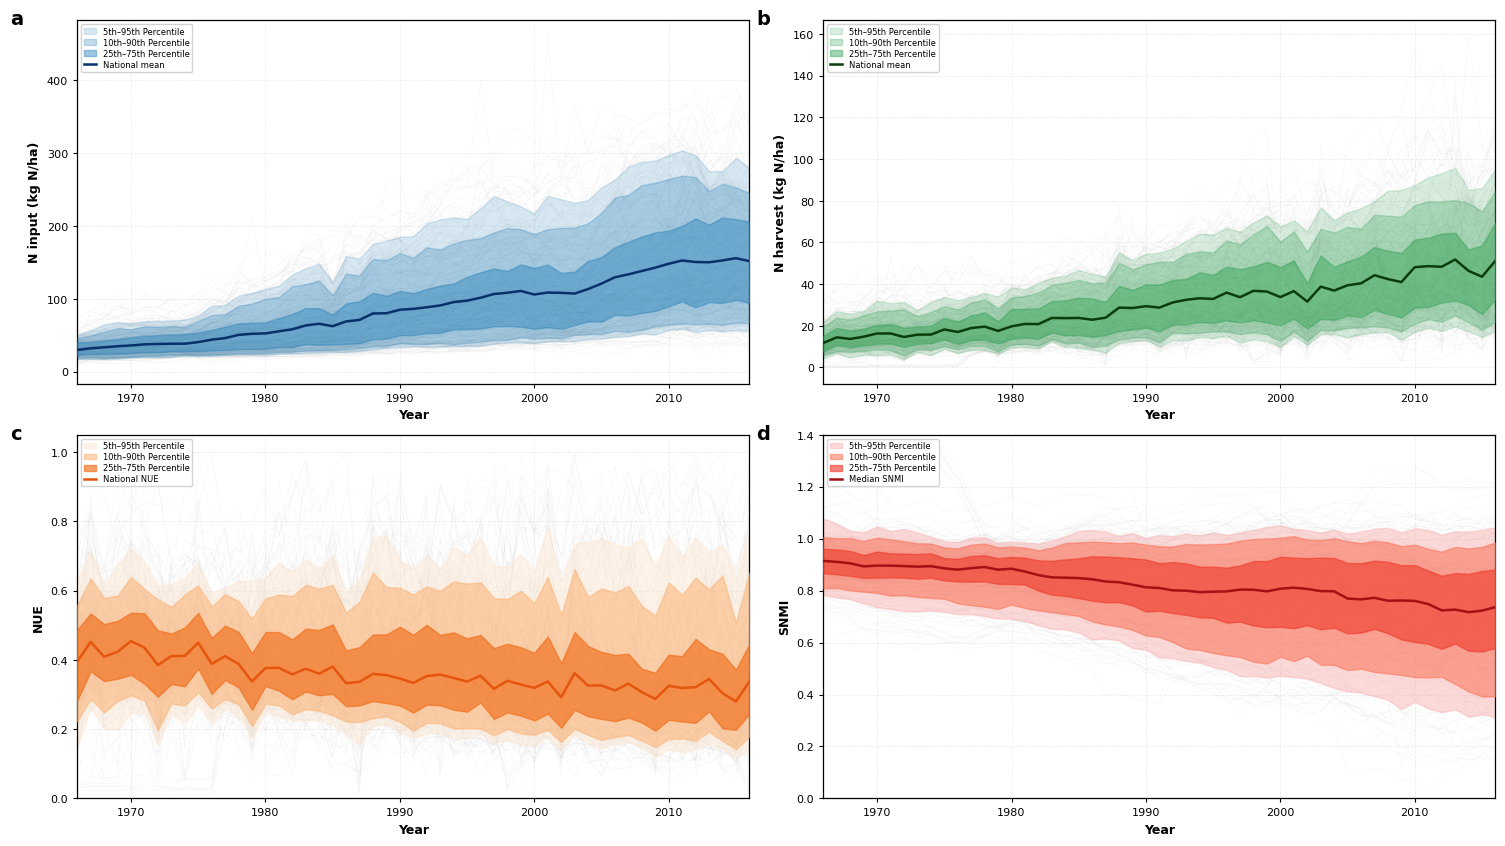


Figure generation complete.
Saved PNG: C:\collaboration\2025\rohini\SNMI\snmi work\data\fig1_outputs\fig1_SNMI_national_panels.png
Saved PDF: C:\collaboration\2025\rohini\SNMI\snmi work\data\fig1_outputs\fig1_SNMI_national_panels.pdf
Saved district metrics: C:\collaboration\2025\rohini\SNMI\snmi work\data\fig1_outputs\fig1_district_metrics_with_SNMI.csv
Saved panel statistics: C:\collaboration\2025\rohini\SNMI\snmi work\data\fig1_outputs\fig1_panel_timeseries_statistics.csv
NYield reference used for SNMI: {'national': 109.46573051700003}


In [2]:
# -*- coding: utf-8 -*-
"""
Submission-ready Fig. 1: district spread and national trends for
(a) N input, (b) N harvest, (c) NUE, and (d) SNMI.

Input data required:
    nsurplus_district_comp.csv

Main outputs:
    fig1_SNMI_national_panels.png
    fig1_SNMI_national_panels.pdf
    fig1_panel_timeseries_statistics.csv
    fig1_district_metrics_with_SNMI.csv

Method summary implemented in this script
-----------------------------------------
1. Total N input = manure + atmospheric deposition + synthetic fertilizer + BNF.
2. N input intensity = total N input / net cropped area.
3. N harvest intensity = mean of the two harvest/removal estimates available in the data.
4. NUE = N harvest / total N input. Values outside [0, 1] are treated as implausible.
5. Percentile envelopes are calculated annually across districts after excluding districts
   whose long-term mean falls outside the 5th-95th percentile range for the plotted metric.
6. National N input and N harvest lines are area-weighted means.
7. NUE national line is the national mass-balance ratio: sum(N harvest) / sum(N input).
8. SNMI is calculated as Euclidean distance from the optimum point (NYield* = 1, NUE* = 1):
       SNMI = sqrt((1 - NYield*)^2 + (1 - NUE*)^2)
   where NYield* is normalized by the 90th percentile of district-level maximum N harvest.
   If a regioncode column exists, the reference is region-specific; otherwise a national
   reference is used. NUE* follows the SNMI convention with an optimal NUE range of 0.5-0.9.

Author: Shekhar Goyal workflow, cleaned for reproducible figure generation.
"""

from __future__ import annotations

from pathlib import Path
from typing import Dict, Iterable, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# ============================================================
# 1. USER SETTINGS
# ============================================================

CSV_PATH = Path(r"C:\collaboration\2025\rohini\SNMI\snmi work\data/nsurplus_district_comp.csv")  # change this path on your system
OUT_DIR = CSV_PATH.parent / "fig1_outputs"
OUT_PREFIX = "fig1_SNMI_national_panels"

YEAR_COL = "Year"
STATE_COL = "State Name"
DIST_COL = "Dist Name"
REGION_COL = "regioncode"  # optional. If absent, script uses national NYield reference.

AREA_COL = "NET CROPPED AREA (1000 ha)"  # thousand ha
MANURE_COL = "Manure_mean"
DEP_COL = "Nitrogen Deposition(kgN)mean"
FERT_COL = "Fertilizer mean"
BNF_COL = "BNF_mean"
HARVEST_TOTAL_COL = "n_removed_kg_mean"
HARVEST_HA_COLS = ["n_removal_kg_ha", "n_removal_kg_ha_fao"]

# SNMI parameters
NYIELD_REF_QUANTILE = 0.90
NUE_OPT_LOW = 0.50
NUE_OPT_HIGH = 0.90
ROLLING_WINDOW_SNMI = 5          # set to None if you do not want SNMI smoothing
ROLLING_MIN_PERIODS_SNMI = 3

# Figure settings
SAVE_DPI = 600
FIGSIZE = (15.5, 8.6)
SPAGHETTI_ALPHA = 0.10
SPAGHETTI_LW = 0.45
BAND_ALPHA = (0.18, 0.28, 0.45)  # 5-95, 10-90, 25-75

COLORS = {
    "input":   {"base": "#2b83ba", "line": "#08306b"},
    "harvest": {"base": "#31a354", "line": "#0b3d0b"},
    "nue":     {"p05": "#fee6ce", "p10": "#fdae6b", "p25": "#f16913", "line": "#e6550d"},
    "snmi":    {"p05": "#fcaeae", "p10": "#fb6a4a", "p25": "#ef3b2c", "line": "#a50f15"},
}


# ============================================================
# 2. DATA PREPARATION
# ============================================================

def require_columns(df: pd.DataFrame, cols: Iterable[str]) -> None:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required column(s): {missing}")


def clean_numeric(df: pd.DataFrame, cols: Iterable[str]) -> pd.DataFrame:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def load_and_prepare(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    required = [
        YEAR_COL, STATE_COL, DIST_COL, AREA_COL,
        MANURE_COL, DEP_COL, FERT_COL, BNF_COL,
        HARVEST_TOTAL_COL, *HARVEST_HA_COLS,
    ]
    require_columns(df, required)

    numeric_cols = [YEAR_COL, AREA_COL, MANURE_COL, DEP_COL, FERT_COL, BNF_COL,
                    HARVEST_TOTAL_COL, *HARVEST_HA_COLS]
    df = clean_numeric(df, numeric_cols)
    df = df.dropna(subset=[YEAR_COL, STATE_COL, DIST_COL]).copy()
    df[YEAR_COL] = df[YEAR_COL].astype(int)

    # Unique district identifier avoids mixing districts with the same name in different states.
    df["district_id"] = (
        df[STATE_COL].astype(str).str.strip() + " | " + df[DIST_COL].astype(str).str.strip()
    )

    # Area in ha. Original column is thousand ha.
    df["Area_ha"] = df[AREA_COL] * 1000.0
    df.loc[df["Area_ha"] <= 0, "Area_ha"] = np.nan

    # Total input and intensity.
    input_cols = [MANURE_COL, DEP_COL, FERT_COL, BNF_COL]
    df["Total_N_input_kg"] = df[input_cols].sum(axis=1, min_count=1)
    df["N_input_kg_ha"] = df["Total_N_input_kg"] / df["Area_ha"]

    # Harvest intensity. Prefer the direct kg/ha columns for district-level spread.
    df["N_harvest_kg_ha"] = df[HARVEST_HA_COLS].mean(axis=1, skipna=True)

    # Total harvest. Prefer existing mass column; fallback from intensity x area.
    df["Total_N_harvest_kg"] = df[HARVEST_TOTAL_COL]
    fallback = df["Total_N_harvest_kg"].isna() & df["N_harvest_kg_ha"].notna() & df["Area_ha"].notna()
    df.loc[fallback, "Total_N_harvest_kg"] = df.loc[fallback, "N_harvest_kg_ha"] * df.loc[fallback, "Area_ha"]

    # NUE at district level.
    df["NUE"] = df["Total_N_harvest_kg"] / df["Total_N_input_kg"]
    df.loc[(df["NUE"] < 0) | (df["NUE"] > 1) | ~np.isfinite(df["NUE"]), "NUE"] = np.nan

    # Guard against invalid values.
    for c in ["N_input_kg_ha", "N_harvest_kg_ha"]:
        df.loc[(df[c] < 0) | ~np.isfinite(df[c]), c] = np.nan

    return df


# ============================================================
# 3. SNMI CALCULATION
# ============================================================

def nue_star(nue: pd.Series, low: float = NUE_OPT_LOW, high: float = NUE_OPT_HIGH) -> pd.Series:
    """
    Normalize NUE for SNMI.
    NUE within the optimal interval [low, high] receives 1.
    Below low: increases linearly from 0 to 1.
    Above high: decreases linearly from 1 at high to 0 at NUE = 1.
    """
    out = pd.Series(np.nan, index=nue.index, dtype=float)
    valid = nue.notna() & np.isfinite(nue)
    out.loc[valid & (nue < low)] = nue.loc[valid & (nue < low)] / low
    out.loc[valid & (nue >= low) & (nue <= high)] = 1.0
    out.loc[valid & (nue > high)] = (1.0 - nue.loc[valid & (nue > high)]) / (1.0 - high)
    return out.clip(lower=0, upper=1)


def add_snmi(df: pd.DataFrame) -> Tuple[pd.DataFrame, Dict[str, float]]:
    df = df.copy()

    # Reference N yield: 90th percentile of district maximum harvest intensity.
    if REGION_COL in df.columns and df[REGION_COL].notna().any():
        max_yield = (
            df.groupby([REGION_COL, "district_id"], dropna=True)["N_harvest_kg_ha"]
              .max()
              .reset_index(name="district_max_yield")
        )
        refs = (
            max_yield.groupby(REGION_COL)["district_max_yield"]
            .quantile(NYIELD_REF_QUANTILE)
            .to_dict()
        )
        df["NYield_ref"] = df[REGION_COL].map(refs)
        ref_note = {str(k): float(v) for k, v in refs.items()}
    else:
        district_max = df.groupby("district_id")["N_harvest_kg_ha"].max()
        national_ref = float(district_max.quantile(NYIELD_REF_QUANTILE))
        df["NYield_ref"] = national_ref
        ref_note = {"national": national_ref}

    df["NYield_star"] = (df["N_harvest_kg_ha"] / df["NYield_ref"]).clip(lower=0, upper=1)
    df["NUE_star"] = nue_star(df["NUE"])
    df["SNMI"] = np.sqrt((1.0 - df["NYield_star"]) ** 2 + (1.0 - df["NUE_star"]) ** 2)

    if ROLLING_WINDOW_SNMI:
        df = df.sort_values(["district_id", YEAR_COL]).copy()
        df["SNMI_plot"] = (
            df.groupby("district_id")["SNMI"]
              .transform(lambda s: s.rolling(ROLLING_WINDOW_SNMI, center=True,
                                             min_periods=ROLLING_MIN_PERIODS_SNMI).mean()
                         .interpolate(limit_direction="both"))
        )
    else:
        df["SNMI_plot"] = df["SNMI"]

    return df, ref_note


# ============================================================
# 4. STATISTICS FOR PLOTTING
# ============================================================

def filter_districts_by_longrun_metric(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    district_mean = df.groupby("district_id")[metric].mean()
    lo, hi = district_mean.quantile([0.05, 0.95])
    keep = district_mean[(district_mean >= lo) & (district_mean <= hi)].index
    return df[df["district_id"].isin(keep)].copy()


def percentile_stats(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    dff = filter_districts_by_longrun_metric(df, metric)
    stats = (
        dff.groupby(YEAR_COL)[metric]
        .agg(
            p05=lambda s: s.quantile(0.05),
            p10=lambda s: s.quantile(0.10),
            p25=lambda s: s.quantile(0.25),
            median="median",
            p75=lambda s: s.quantile(0.75),
            p90=lambda s: s.quantile(0.90),
            p95=lambda s: s.quantile(0.95),
            n="count",
        )
        .reset_index()
        .sort_values(YEAR_COL)
    )
    return stats


def national_line(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    if metric == "N_input_kg_ha":
        out = df.groupby(YEAR_COL).agg(num=("Total_N_input_kg", "sum"), den=("Area_ha", "sum")).reset_index()
        out["value"] = out["num"] / out["den"]
    elif metric == "N_harvest_kg_ha":
        out = df.groupby(YEAR_COL).agg(num=("Total_N_harvest_kg", "sum"), den=("Area_ha", "sum")).reset_index()
        out["value"] = out["num"] / out["den"]
    elif metric == "NUE":
        out = df.groupby(YEAR_COL).agg(num=("Total_N_harvest_kg", "sum"), den=("Total_N_input_kg", "sum")).reset_index()
        out["value"] = out["num"] / out["den"]
        out.loc[(out["value"] < 0) | (out["value"] > 1), "value"] = np.nan
    elif metric == "SNMI_plot":
        # The figure panel uses the annual median SNMI, matching the district envelope logic.
        out = percentile_stats(df, metric)[[YEAR_COL, "median"]].rename(columns={"median": "value"})
    else:
        raise ValueError(f"Unsupported national metric: {metric}")
    return out[[YEAR_COL, "value"]].sort_values(YEAR_COL)


# ============================================================
# 5. PLOTTING
# ============================================================

def style_axis(ax: plt.Axes) -> None:
    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(0.9)
    ax.grid(True, alpha=0.22, linestyle="--", linewidth=0.6)
    ax.tick_params(axis="both", labelsize=8, width=0.8, length=3)
    ax.set_axisbelow(True)


def plot_panel(
    ax: plt.Axes,
    df: pd.DataFrame,
    metric: str,
    ylabel: str,
    label_line: str,
    panel_letter: str,
    color_key: str,
    ylim: Optional[Tuple[float, float]] = None,
) -> pd.DataFrame:
    dff = filter_districts_by_longrun_metric(df, metric)
    stats = percentile_stats(df, metric)
    nat = national_line(df, metric)

    # Background district trajectories.
    for _, g in dff.sort_values(YEAR_COL).groupby("district_id"):
        ax.plot(g[YEAR_COL], g[metric], color="0.70", linewidth=SPAGHETTI_LW,
                alpha=SPAGHETTI_ALPHA, zorder=1)

    x = stats[YEAR_COL].to_numpy(dtype=float)

    if color_key in ["input", "harvest"]:
        base = COLORS[color_key]["base"]
        ax.fill_between(x, stats["p05"].to_numpy(float), stats["p95"].to_numpy(float),
                        color=base, alpha=BAND_ALPHA[0], label="5th–95th Percentile", zorder=2)
        ax.fill_between(x, stats["p10"].to_numpy(float), stats["p90"].to_numpy(float),
                        color=base, alpha=BAND_ALPHA[1], label="10th–90th Percentile", zorder=3)
        ax.fill_between(x, stats["p25"].to_numpy(float), stats["p75"].to_numpy(float),
                        color=base, alpha=BAND_ALPHA[2], label="25th–75th Percentile", zorder=4)
        line_color = COLORS[color_key]["line"]
    else:
        ax.fill_between(x, stats["p05"].to_numpy(float), stats["p95"].to_numpy(float),
                        color=COLORS[color_key]["p05"], alpha=0.45, label="5th–95th Percentile", zorder=2)
        ax.fill_between(x, stats["p10"].to_numpy(float), stats["p90"].to_numpy(float),
                        color=COLORS[color_key]["p10"], alpha=0.50, label="10th–90th Percentile", zorder=3)
        ax.fill_between(x, stats["p25"].to_numpy(float), stats["p75"].to_numpy(float),
                        color=COLORS[color_key]["p25"], alpha=0.62, label="25th–75th Percentile", zorder=4)
        line_color = COLORS[color_key]["line"]

    ax.plot(nat[YEAR_COL], nat["value"], color=line_color, linewidth=1.8,
            label=label_line, zorder=6)

    ax.set_xlabel("Year", fontsize=9, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=9, fontweight="bold")
    ax.set_xlim(df[YEAR_COL].min(), df[YEAR_COL].max())
    if ylim is not None:
        ax.set_ylim(*ylim)
    style_axis(ax)
    ax.text(-0.10, 1.03, panel_letter, transform=ax.transAxes,
            fontsize=14, fontweight="bold", va="top", ha="left")
    ax.legend(loc="upper left", fontsize=6, frameon=True, framealpha=0.85,
              borderpad=0.3, handlelength=1.5, labelspacing=0.25)

    stats_out = stats.copy()
    stats_out["metric"] = metric
    stats_out = stats_out.merge(nat.rename(columns={"value": "national_line"}), on=YEAR_COL, how="left")
    return stats_out


def make_figure(df: pd.DataFrame, out_dir: Path) -> pd.DataFrame:
    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": 8,
        "axes.linewidth": 0.9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.bbox": "tight",
    })

    fig, axes = plt.subplots(2, 2, figsize=FIGSIZE, constrained_layout=False)
    axes = axes.ravel()

    all_stats = []
    all_stats.append(plot_panel(axes[0], df, "N_input_kg_ha", "N input (kg N/ha)",
                                "National mean", "a", "input", ylim=None))
    all_stats.append(plot_panel(axes[1], df, "N_harvest_kg_ha", "N harvest (kg N/ha)",
                                "National mean", "b", "harvest", ylim=None))
    all_stats.append(plot_panel(axes[2], df, "NUE", "NUE",
                                "National NUE", "c", "nue", ylim=(0, 1.05)))
    all_stats.append(plot_panel(axes[3], df, "SNMI_plot", "SNMI",
                                "Median SNMI", "d", "snmi", ylim=(0, 1.4)))

    plt.subplots_adjust(left=0.07, right=0.985, bottom=0.08, top=0.985, wspace=0.11, hspace=0.14)

    out_png = out_dir / f"{OUT_PREFIX}.png"
    out_pdf = out_dir / f"{OUT_PREFIX}.pdf"
    fig.savefig(out_png, dpi=SAVE_DPI)
    fig.savefig(out_pdf)
    plt.show()
    plt.close(fig)

    return pd.concat(all_stats, ignore_index=True)


# ============================================================
# 6. RUN
# ============================================================

def main() -> None:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    df = load_and_prepare(CSV_PATH)
    df, refs = add_snmi(df)

    stats = make_figure(df, OUT_DIR)

    df.to_csv(OUT_DIR / "fig1_district_metrics_with_SNMI.csv", index=False)
    stats.to_csv(OUT_DIR / "fig1_panel_timeseries_statistics.csv", index=False)

    print("\nFigure generation complete.")
    print(f"Saved PNG: {OUT_DIR / (OUT_PREFIX + '.png')}")
    print(f"Saved PDF: {OUT_DIR / (OUT_PREFIX + '.pdf')}")
    print(f"Saved district metrics: {OUT_DIR / 'fig1_district_metrics_with_SNMI.csv'}")
    print(f"Saved panel statistics: {OUT_DIR / 'fig1_panel_timeseries_statistics.csv'}")
    print("NYield reference used for SNMI:", refs)


if __name__ == "__main__":
    main()
